# 🎬 Movie Rating Tool

This notebook demonstrates all the features of the Movie Rating Tool.

It walks through:
1. Loading and searching the MovieLens dataset
2. Creating and managing personal ratings
3. Comparing personal ratings with online ratings
4. Statistical analysis with NumPy and Pandas
5. Visualizations with Matplotlib and Seaborn
6. Movie recommendations

## 0 — Setup
Make sure you have installed the package first:
```bash
uv sync
```

In [1]:
# Add the src folder to the path so imports work from the notebook
import sys
sys.path.insert(0, '../src')

# Core imports
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Movie Rating Tool modules
from movie_rating_tool import data_loader, rating_engine, analysis
from movie_rating_tool.models import Movie, UserRating, RatingCollection
from movie_rating_tool import visualization

print('✅ All imports successful!')


✅ All imports successful!


## 1 — Exploring the MovieLens Dataset

In [2]:
# Load the full movie cache as a Pandas DataFrame
movies_df = data_loader.get_movies_df()

print(f'Total movies in dataset: {len(movies_df):,}')
movies_df.head(10)

Total movies in dataset: 2,269


,movie_id,title,title.1,year,genres,online_rating,num_votes
0,356,Forrest Gump (1994),Forrest Gump,1994,Comedy|Drama|Romance|War,8.3,329
1,318,"Shawshank Redemption, The (1994)","Shawshank Redemption, The",1994,Crime|Drama,8.9,317
2,296,Pulp Fiction (1994),Pulp Fiction,1994,Comedy|Crime|Drama|Thriller,8.4,307
3,593,"Silence of the Lambs, The (1991)","Silence of the Lambs, The",1991,Crime|Horror|Thriller,8.3,279
4,2571,"Matrix, The (1999)","Matrix, The",1999,Action|Sci-Fi|Thriller,8.4,278
5,260,Star Wars: Episode IV - A New Hope (1977),Star Wars: Episode IV - A New Hope,1977,Action|Adventure|Sci-Fi,8.5,251
6,480,Jurassic Park (1993),Jurassic Park,1993,Action|Adventure|Sci-Fi|Thriller,7.5,238
7,110,Braveheart (1995),Braveheart,1995,Action|Drama|War,8.1,237
8,589,Terminator 2: Judgment Day (1991),Terminator 2: Judgment Day,1991,Action|Sci-Fi,7.9,224
9,527,Schindler's List (1993),Schindler's List,1993,Drama|War,8.4,220


In [3]:
# Basic dataset statistics
print('=== Dataset Overview ===')
print(f"Year range  : {int(movies_df['year'].min())} – {int(movies_df['year'].max())}")
print(f"Rating range: {movies_df['online_rating'].min()} – {movies_df['online_rating'].max()}")
print(f"Avg rating  : {movies_df['online_rating'].mean():.2f}")
print()
movies_df.describe()

=== Dataset Overview ===
Year range  : 1922 – 2018
Rating range: 2.7 – 9.2
Avg rating  : 6.86



,movie_id,year,online_rating,num_votes
count,2269.000000,2269.000000,2269.000000,2269.000000
mean,20530.586161,1994.865580,6.863508,35.749669
std,35185.840333,14.665013,1.012231,35.986989
min,1.000000,1922.000000,2.700000,10.000000
25%,1345.000000,1990.000000,6.200000,14.000000
50%,3256.000000,1997.000000,7.000000,22.000000
75%,8958.000000,2004.000000,7.600000,43.000000
max,187593.000000,2018.000000,9.200000,329.000000


In [4]:
# Top 10 highest rated movies (with at least 100 votes)
top_movies = (
    movies_df[movies_df['num_votes'] >= 100]
    .sort_values('online_rating', ascending=False)
    .head(10)[['title', 'year', 'online_rating', 'num_votes', 'genres']]
)
print('🏆 Top 10 Highest Rated Movies')
top_movies

🏆 Top 10 Highest Rated Movies


,title,year,online_rating,num_votes,genres
1,"Shawshank Redemption, The (1994)",1994,8.9,317,Crime|Drama
21,"Godfather, The (1972)",1972,8.6,192,Crime|Drama
73,"Godfather: Part II, The (1974)",1974,8.5,129,Crime|Drama
113,"Departed, The (2006)",2006,8.5,107,Crime|Drama|Thriller
5,Star Wars: Episode IV - A New Hope (1977),1977,8.5,251,Action|Adventure|Sci-Fi
44,"Dark Knight, The (2008)",2008,8.5,149,Action|Crime|Drama|IMAX
52,"Princess Bride, The (1987)",1987,8.5,142,Action|Adventure|Comedy|Fantasy|Romance
10,Fight Club (1999),1999,8.5,218,Action|Crime|Drama|Thriller
135,Casablanca (1942),1942,8.5,100,Drama|Romance
76,Goodfellas (1990),1990,8.5,126,Crime|Drama


In [5]:
# Search for movies by title
results = data_loader.search_movies('matrix', limit=5)
print('🔍 Search results for "matrix":')
for r in results:
    print(f"  {r['title']} ({r['year']}) — ⭐ {r['online_rating']}/10")

🔍 Search results for "matrix":
  Matrix, The (1999) (1999) — ⭐ 8.4/10
  Matrix Reloaded, The (2003) (2003) — ⭐ 6.7/10
  Matrix Revolutions, The (2003) (2003) — ⭐ 6.3/10
  Animatrix, The (2003) (2003) — ⭐ 7.4/10


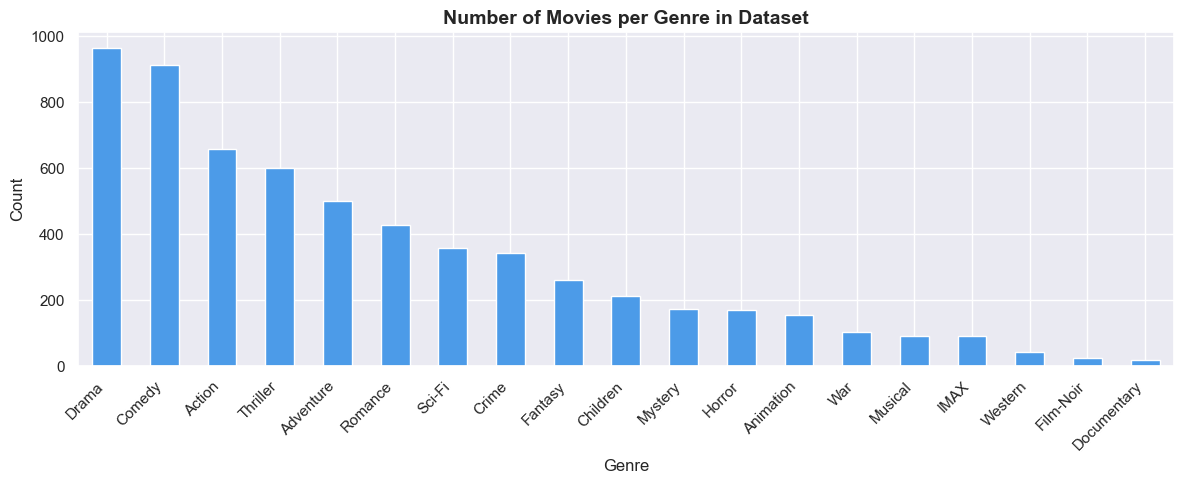

In [6]:
# Genre distribution across the whole dataset
all_genres = []
for genres_str in movies_df['genres'].dropna():
    for genre in genres_str.split('|'):
        if genre and genre != '(no genres listed)':
            all_genres.append(genre)

genre_series = pd.Series(all_genres)
genre_counts = genre_series.value_counts()

fig, ax = plt.subplots(figsize=(12, 5))
genre_counts.plot(kind='bar', ax=ax, color='#4C9BE8', edgecolor='white')
ax.set_title('Number of Movies per Genre in Dataset', fontsize=14, fontweight='bold')
ax.set_xlabel('Genre')
ax.set_ylabel('Count')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

## 2 — Data Models: Movie, UserRating, RatingCollection

In [7]:
# Demonstrate the Movie class
movie = Movie(
    movie_id=1,
    title='Toy Story',
    year=1995,
    genres={'Animation', 'Comedy', 'Family'},
    online_rating=7.8,
    num_votes=452,
)
print('Movie object:', movie)
print('As dict     :', movie.to_dict())
print('Genres (set):', movie.genres)

Movie object: Movie(title='Toy Story', year=1995, rating=7.8, genres={'Comedy', 'Animation', 'Family'})
As dict     : {'movie_id': 1, 'title': 'Toy Story', 'year': 1995, 'genres': 'Animation,Comedy,Family', 'online_rating': 7.8, 'num_votes': 452}
Genres (set): {'Comedy', 'Animation', 'Family'}


In [8]:
# Demonstrate UserRating with tuple date storage
rating = UserRating(
    movie_id=1,
    title='Toy Story',
    user_score=8.5,
    review='A classic! Great for all ages.',
)
print('UserRating object :', rating)
print('Date as tuple     :', rating.rated_on)
print('Date as string    :', rating.get_date_str())
print('As dict           :', rating.to_dict())

UserRating object : UserRating(title='Toy Story', score=8.5, date=(2026, 3, 27))
Date as tuple     : (2026, 3, 27)
Date as string    : 2026-03-27
As dict           : {'movie_id': 1, 'title': 'Toy Story', 'user_score': 8.5, 'review': 'A classic! Great for all ages.', 'rated_on': '2026-03-27'}


In [9]:
# Demonstrate RatingCollection (list + set internally)
collection = RatingCollection()

sample_ratings = [
    UserRating(movie_id=1,    title='Toy Story',                user_score=8.5),
    UserRating(movie_id=296,  title='Pulp Fiction',             user_score=9.0),
    UserRating(movie_id=318,  title='The Shawshank Redemption', user_score=9.5),
    UserRating(movie_id=527,  title="Schindler's List",         user_score=8.0),
    UserRating(movie_id=593,  title='The Silence of the Lambs', user_score=7.5),
    UserRating(movie_id=2571, title='The Matrix',               user_score=8.5),
]

for r in sample_ratings:
    collection.add(r)

print(f'Collection: {collection}')
print(f'Has Toy Story (id=1): {collection.has(1)}')
print(f'Duplicate add returns False: {collection.add(sample_ratings[0])}')

data_loader.save_ratings(collection)
print('\n✅ Sample ratings saved!')

Collection: RatingCollection(6 ratings)
Has Toy Story (id=1): True
Duplicate add returns False: False
✅ Ratings saved to my_ratings.csv

✅ Sample ratings saved!


## 3 — Comparing Personal vs Online Ratings

In [10]:
# Build the comparison DataFrame
comparison_df = rating_engine.get_comparison_df(collection)
print('Comparison DataFrame:')
comparison_df[['title', 'user_score', 'online_rating', 'difference']]

Comparison DataFrame:


,title,user_score,online_rating,difference
0,Toy Story,8.5,7.8,0.7
1,Pulp Fiction,9.0,8.4,0.6
2,The Shawshank Redemption,9.5,8.9,0.6
3,Schindler's List,8.0,8.4,-0.4
4,The Silence of the Lambs,7.5,8.3,-0.8
5,The Matrix,8.5,8.4,0.1


In [11]:
# Demonstrate get_rating_label
test_scores = [9.5, 8.0, 7.0, 6.0, 5.0, 3.0, 1.0]
print('Score → Label mapping:')
for score in test_scores:
    label = rating_engine.get_rating_label(score)
    print(f'  {score} → {label}')

Score → Label mapping:
  9.5 → Masterpiece 🏆
  8.0 → Excellent ⭐
  7.0 → Good 👍
  6.0 → Decent 🙂
  5.0 → Average 😐
  3.0 → Poor 👎
  1.0 → Terrible 💀


## 4 — Statistical Analysis with NumPy & Pandas

In [12]:
# Compute full statistics
stats = analysis.compute_stats(collection)

print('=== Your Rating Statistics ===')
print(f"Count          : {stats['count']}")
print(f"Mean           : {stats['mean']}")
print(f"Median         : {stats['median']}")
print(f"Std deviation  : {stats['std']}")
print(f"Min score      : {stats['min_score']} ({stats['min_title']})")
print(f"Max score      : {stats['max_score']} ({stats['max_title']})")
print(f"Avg online     : {stats['mean_online']}")
print(f"Avg difference : {stats['mean_diff']}")
print(f"\nScore distribution: {stats['score_distribution']}")

=== Your Rating Statistics ===
Count          : 6
Mean           : 8.5
Median         : 8.5
Std deviation  : 0.65
Min score      : 7.5 (The Silence of the Lambs)
Max score      : 9.5 (The Shawshank Redemption)
Avg online     : 8.37
Avg difference : 0.13

Score distribution: {'0–2': 0, '2–4': 0, '4–6': 0, '6–8': 1, '8–10': 5}


In [13]:
# NumPy operations on raw scores
scores = stats['scores_array']
print('NumPy array of scores:', scores)
print(f'np.mean   : {np.mean(scores):.2f}')
print(f'np.median : {np.median(scores):.2f}')
print(f'np.std    : {np.std(scores):.2f}')
print(f'np.min    : {np.min(scores)}')
print(f'np.max    : {np.max(scores)}')
print(f'\n75th percentile : {np.percentile(scores, 75)}')
print(f'25th percentile : {np.percentile(scores, 25)}')

NumPy array of scores: [8.5 9.  9.5 8.  7.5 8.5]
np.mean   : 8.50
np.median : 8.50
np.std    : 0.65
np.min    : 7.5
np.max    : 9.5

75th percentile : 8.875
25th percentile : 8.125


In [14]:
# Genre stats as a Pandas DataFrame
genre_df = analysis.get_genre_stats(collection)
print('Genre statistics:')
genre_df

Genre statistics:


,genre,avg_user_score,avg_online_rating,count
5,Crime,8.67,8.53,3
6,Drama,8.83,8.57,3
10,Thriller,8.33,8.37,3
4,Comedy,8.75,8.10,2
0,Action,8.50,8.40,1
1,Adventure,8.50,7.80,1
2,Animation,8.50,7.80,1
3,Children,8.50,7.80,1
7,Fantasy,8.50,7.80,1
8,Horror,7.50,8.30,1


## 5 — Visualizations

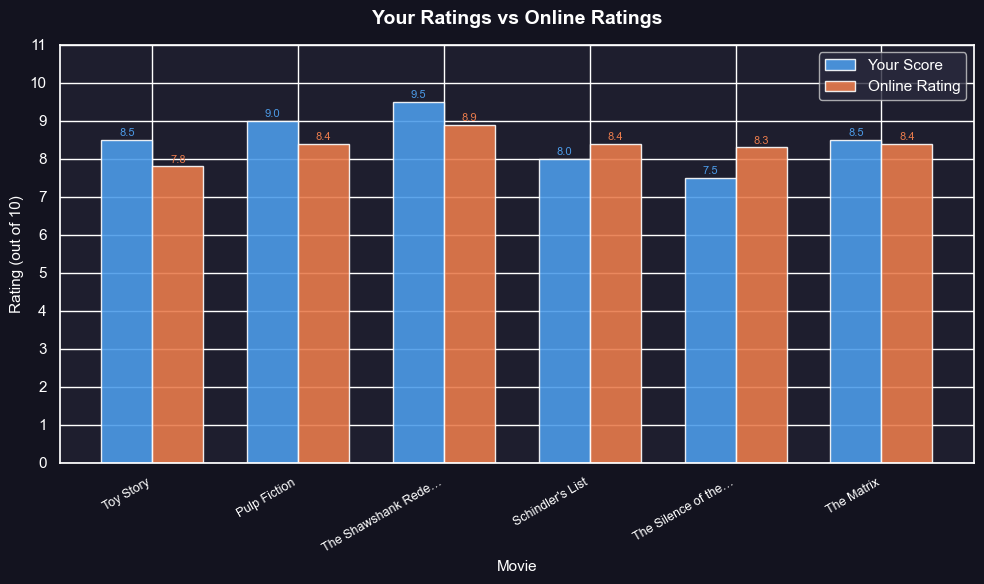

In [15]:
visualization.plot_rating_comparison(collection)

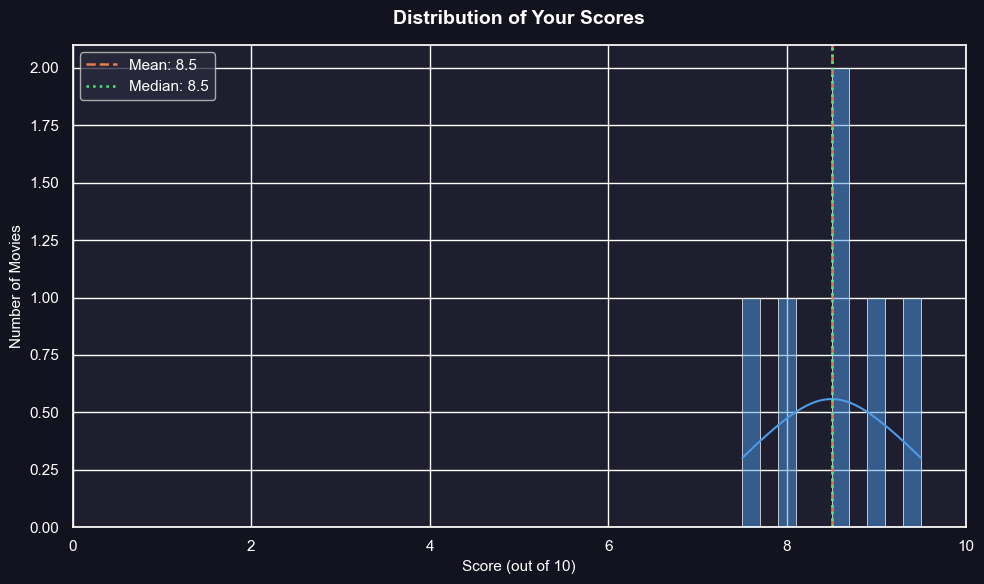

In [16]:
visualization.plot_score_distribution(collection)

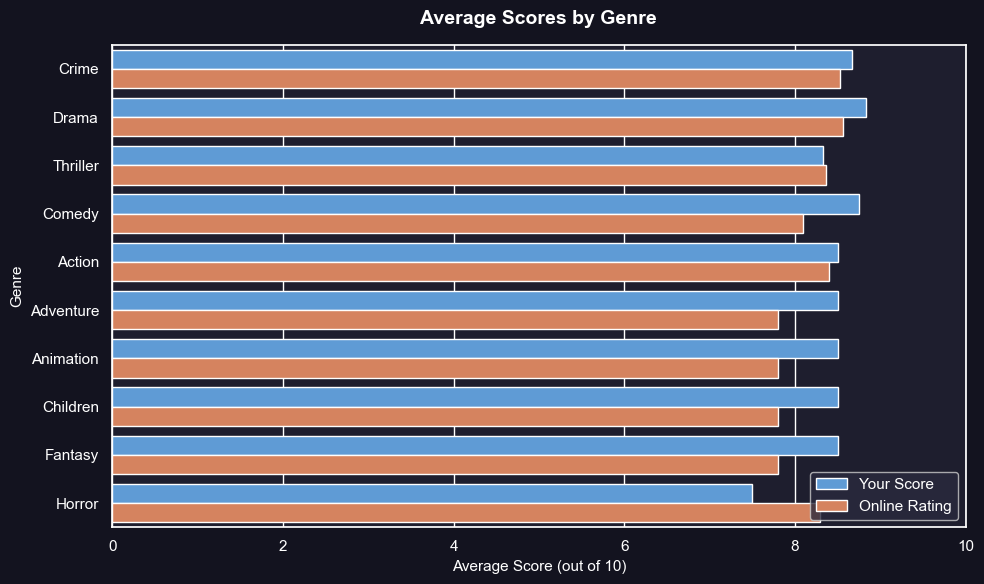

In [17]:
visualization.plot_genre_analysis(collection)

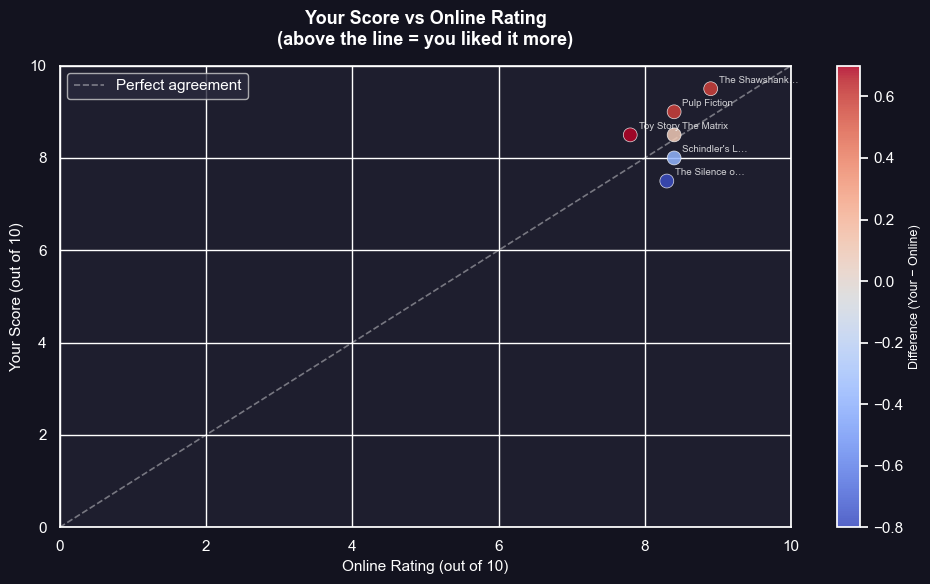

In [18]:
visualization.plot_scatter(collection)

## 6 — Recommendations

In [19]:
recommendations = rating_engine.get_recommendations(collection, limit=8)

print('🎯 Recommended movies based on your taste:\n')
for i, movie in enumerate(recommendations, start=1):
    print(f"  {i}. {movie['title']} ({int(movie['year'])}) "
          f"— ⭐ {movie['online_rating']}/10 "
          f"[{movie['genres'].replace('|', ', ')}]")

🎯 Recommended movies based on your taste:

  1. Secrets & Lies (1996) (1996) — ⭐ 9.2/10 [Drama]
  2. Guess Who's Coming to Dinner (1967) (1967) — ⭐ 9.1/10 [Drama]
  3. Paths of Glory (1957) (1957) — ⭐ 9.1/10 [Drama, War]
  4. Streetcar Named Desire, A (1951) (1951) — ⭐ 9.0/10 [Drama]
  5. Celebration, The (Festen) (1998) (1998) — ⭐ 8.9/10 [Drama]
  6. Ran (1985) (1985) — ⭐ 8.9/10 [Drama, War]
  7. His Girl Friday (1940) (1940) — ⭐ 8.8/10 [Comedy, Romance]
  8. Hustler, The (1961) (1961) — ⭐ 8.7/10 [Drama]


## 7 — Data Storage: Save & Load

In [20]:
data_loader.save_ratings(collection)

reloaded = data_loader.load_ratings()
print(f'Original collection : {collection}')
print(f'Reloaded collection : {reloaded}')
print(f'Counts match        : {collection.count() == reloaded.count()}')

from movie_rating_tool.data_loader import RATINGS_FILE
pd.read_csv(RATINGS_FILE)

✅ Ratings saved to my_ratings.csv
Original collection : RatingCollection(6 ratings)
Reloaded collection : RatingCollection(6 ratings)
Counts match        : True


,movie_id,title,user_score,review,rated_on
0,1,Toy Story,8.5,NaN,2026-03-27
1,296,Pulp Fiction,9.0,NaN,2026-03-27
2,318,The Shawshank Redemption,9.5,NaN,2026-03-27
3,527,Schindler's List,8.0,NaN,2026-03-27
4,593,The Silence of the Lambs,7.5,NaN,2026-03-27
5,2571,The Matrix,8.5,NaN,2026-03-27


## Summary

| Feature | Module | Concepts Used |
|---------|--------|---------------|
| Dataset loading & search | `data_loader.py` | Pandas, file I/O |
| Data models | `models.py` | Classes, OOP, tuples, sets, lists, dicts |
| Rating comparison | `rating_engine.py` | Pandas merge, conditionals |
| Statistics | `analysis.py` | NumPy, Pandas groupby |
| Visualizations | `visualization.py` | Matplotlib, Seaborn |
| Recommendations | `rating_engine.py` | Sets, loops, filtering |
| Data storage | `data_loader.py` | CSV read/write with Pandas |